# BayesOpt Design Study

Systematic investigation of Gaussian-Process Bayesian optimisation design choices
for hyperparameter and neural-network training landscapes.

**Five studies:**

| # | Question | Variables |
|---|----------|-----------|
| 1 | Which acquisition function? | UCB · EI · PI |
| 2 | How to set acquisition hyperparameters? | κ (UCB), ξ (EI / PI) |
| 3 | Which kernel? | RBF · Matérn ν = 0.5 / 1.5 / 2.5 |
| 4 | How does parallelisation affect convergence? | n\_parallel = 1 / 2 / 4 / 8 |
| 5 | Which Kriging-Believer hallucination strategy? | Mean · Sample · UCB · Constant |

Evaluated on **four benchmark functions** that proxy real HPO / NN landscapes.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from hyperoptax.acquisition import (
    EI, PI, UCB,
    ConstantHallucination, MeanHallucination,
    SampleHallucination, UCBHallucination,
)
from hyperoptax.bayesian import BayesianSearch
from hyperoptax.kernels import Matern, RBF
from hyperoptax.random import RandomSearch
from hyperoptax.spaces import LinearSpace

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print(f"JAX {jax.__version__} | devices: {jax.devices()}")


JAX 0.6.2 | devices: [CpuDevice(id=0)]


## Benchmark Functions

| Function | Dim | Challenge | NN / HPO analogy |
|----------|-----|-----------|------------------|
| **Branin** | 2 | 3 global minima, multimodal | 2-hparam grid (lr × momentum) |
| **Hartmann 6D** | 6 | 6 local minima, high-dimensional | Full HPO: lr, batch size, dropout, wd, … |
| **Rosenbrock** | 2 | Narrow curved valley | Correlated hyperparameters, slow-manifold NNs |
| **Ackley** | 2 | Highly multimodal, near-flat tails | Rugged deep-NN loss landscape |

**Reference:** Branin and Hartmann 6D are the standard evaluation functions in
Snoek et al. 2012 *"Practical Bayesian Optimization of Machine Learning Algorithms"*.
Rosenbrock mimics the banana-shaped valley common in NN weight-space;
Ackley represents the pathological multimodality of large overparameterised models.

All functions are framed as **maximisation** problems (returned as their negation).


In [2]:
# ── Branin ────────────────────────────────────────────────────────────────
# Domain: x1 ∈ [-5, 10], x2 ∈ [0, 15].  Three global minima, f* ≈ 0.3979.
def branin(x1, x2):
    b = 5.1 / (4 * jnp.pi ** 2)
    c = 5.0 / jnp.pi
    return (x2 - b * x1**2 + c * x1 - 6.0)**2 + 10.0 * (1.0 - 1.0/(8.0*jnp.pi)) * jnp.cos(x1) + 10.0

BRANIN_SPACE   = {"x1": LinearSpace(-5.0, 10.0), "x2": LinearSpace(0.0, 15.0)}
BRANIN_FN      = lambda key, cfg: -branin(cfg["x1"], cfg["x2"])
BRANIN_OPT     = -0.397887   # true max of −branin

# ── Hartmann 6D ───────────────────────────────────────────────────────────
# Domain: [0,1]^6.  Six local minima.  Global min ≈ −3.3224.
_H6_ALPHA = jnp.array([1.0, 1.2, 3.0, 3.2])
_H6_A = jnp.array([
    [10.00,  3.00, 17.00,  3.50,  1.70,  8.00],
    [ 0.05, 10.00, 17.00,  0.10,  8.00, 14.00],
    [ 3.00,  3.50,  1.70, 10.00, 17.00,  8.00],
    [17.00,  8.00,  0.05, 10.00,  0.10, 14.00],
])
_H6_P = 1e-4 * jnp.array([
    [1312, 1696, 5569,  124, 8283, 5886],
    [2329, 4135, 8307, 3736, 1004, 9991],
    [2348, 1451, 3522, 2883, 3047, 6650],
    [4047, 8828, 8732, 5743, 1091,  381],
])

def hartmann6(x):
    """x: shape (6,), domain [0,1]^6."""
    inner = jnp.sum(_H6_A * (x[None, :] - _H6_P)**2, axis=1)  # (4,)
    return -jnp.sum(_H6_ALPHA * jnp.exp(-inner))

HARTMANN6_SPACE = {f"x{i}": LinearSpace(0.0, 1.0) for i in range(6)}
HARTMANN6_FN    = lambda key, cfg: -hartmann6(
    jnp.stack([cfg["x0"], cfg["x1"], cfg["x2"], cfg["x3"], cfg["x4"], cfg["x5"]])
)
HARTMANN6_OPT   = 3.32237    # true max of −hartmann6

# ── Rosenbrock ────────────────────────────────────────────────────────────
# Domain: x1 ∈ [-2, 2], x2 ∈ [-1, 3].  Narrow curved valley.  Global min = 0 at (1,1).
def rosenbrock(x1, x2):
    return 100.0 * (x2 - x1**2)**2 + (1.0 - x1)**2

ROSENBROCK_SPACE = {"x1": LinearSpace(-2.0, 2.0), "x2": LinearSpace(-1.0, 3.0)}
ROSENBROCK_FN    = lambda key, cfg: -rosenbrock(cfg["x1"], cfg["x2"])
ROSENBROCK_OPT   = 0.0

# ── Ackley ────────────────────────────────────────────────────────────────
# Domain: [-5, 5]^2.  Highly multimodal.  Global min = 0 at (0, 0).
def ackley(x1, x2):
    return (-20.0 * jnp.exp(-0.2 * jnp.sqrt(0.5 * (x1**2 + x2**2)))
            - jnp.exp(0.5 * (jnp.cos(2*jnp.pi*x1) + jnp.cos(2*jnp.pi*x2)))
            + jnp.e + 20.0)

ACKLEY_SPACE = {"x1": LinearSpace(-5.0, 5.0), "x2": LinearSpace(-5.0, 5.0)}
ACKLEY_FN    = lambda key, cfg: -ackley(cfg["x1"], cfg["x2"])
ACKLEY_OPT   = 0.0

# Registry: name → (space, wrapper, true_optimum)
BENCHMARKS = {
    "Branin":      (BRANIN_SPACE,    BRANIN_FN,    BRANIN_OPT),
    "Hartmann 6D": (HARTMANN6_SPACE, HARTMANN6_FN, HARTMANN6_OPT),
    "Rosenbrock":  (ROSENBROCK_SPACE, ROSENBROCK_FN, ROSENBROCK_OPT),
    "Ackley":      (ACKLEY_SPACE,    ACKLEY_FN,    ACKLEY_OPT),
}
print("Benchmark functions registered:", list(BENCHMARKS))


Benchmark functions registered: ['Branin', 'Hartmann 6D', 'Rosenbrock', 'Ackley']


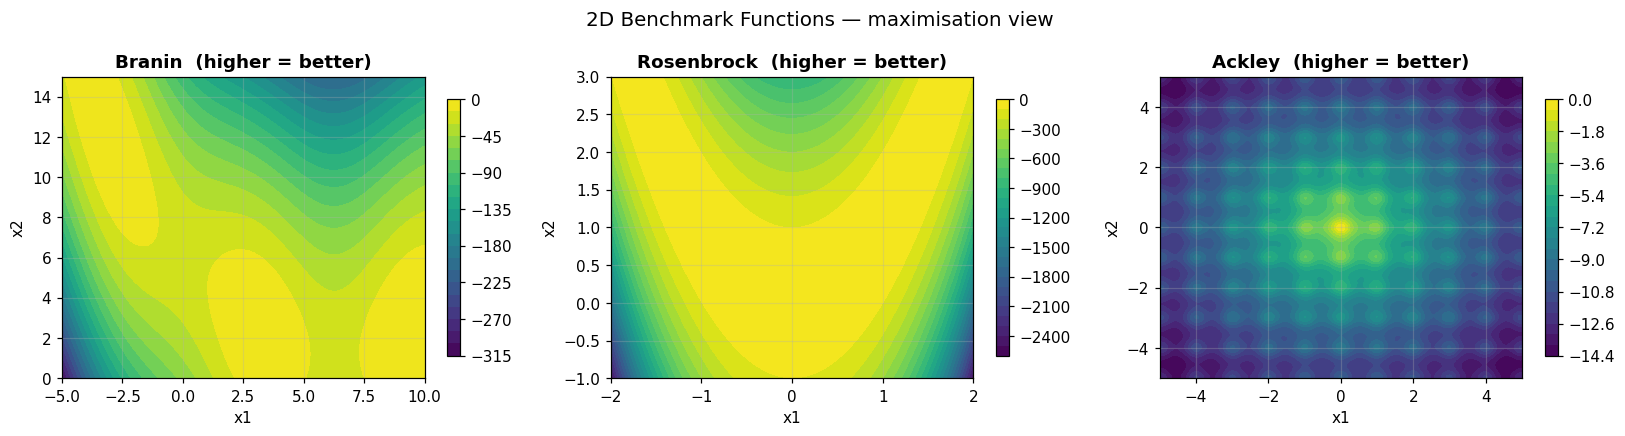

Hartmann 6D is 6-dimensional and not shown directly.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
funcs_2d = [
    ("Branin",     branin,     (-5, 10), (0, 15)),
    ("Rosenbrock", rosenbrock, (-2,  2), (-1, 3)),
    ("Ackley",     ackley,     (-5,  5), (-5, 5)),
]
for ax, (name, fn, (x1lo, x1hi), (x2lo, x2hi)) in zip(axes, funcs_2d):
    x1 = np.linspace(x1lo, x1hi, 250)
    x2 = np.linspace(x2lo, x2hi, 250)
    X1, X2 = np.meshgrid(x1, x2)
    Z = -np.array(fn(jnp.array(X1), jnp.array(X2)))
    cf = ax.contourf(X1, X2, Z, levels=25, cmap="viridis")
    plt.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_title(f"{name}  (higher = better)", fontweight="bold")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
fig.suptitle("2D Benchmark Functions — maximisation view", fontsize=13)
plt.tight_layout()
plt.show()
print("Hartmann 6D is 6-dimensional and not shown directly.")


## Experiment Infrastructure

Each study shares the same evaluation protocol:

- **Budget**: 50 total function evaluations (studies 1–3, 5); 80 for study 4
- **Seeds**: 5 independent runs; plots show median ± IQR
- **Metric**: *Simple regret* = `true_optimum − running_best_found`
- **Warmup**: 3 random iterations before GP kicks in
- **Baseline**: Random search (i.i.d. uniform sampling)

`jax.vmap` over seeds + `optimize_scan` (lax.scan) makes each study compile once
and run all seeds in a single XLA kernel.


In [4]:
N_BUDGET = 50     # default total evaluations per study
N_SEEDS  = 5      # random seeds
N_WARMUP = 3      # random warm-up iterations before BO
SEED     = 42


def run_bo(space, wrapper, true_opt, n_budget=N_BUDGET, n_seeds=N_SEEDS,
           n_parallel=1, n_warmup=N_WARMUP, **bo_kwargs):
    """
    Run BayesianSearch with given config; return (regret, eval_x).

    regret  : ndarray (n_seeds, n_gp_steps)  — simple regret after each batch
    eval_x  : ndarray (n_gp_steps,)          — cumulative evaluations
    """
    n_iter = n_budget // n_parallel
    state0, opt = BayesianSearch.init(
        space, n_max=n_budget, n_parallel=n_parallel, n_warmup=n_warmup, **bo_kwargs
    )
    keys = jax.random.split(jax.random.PRNGKey(SEED), n_seeds)

    @jax.jit
    def _run(keys):
        def one(key):
            _, (_, res) = opt.optimize_scan(state0, key, wrapper, n_iter)
            return res                          # (n_iter, n_parallel)
        return jax.vmap(one)(keys)             # (n_seeds, n_iter, n_parallel)

    raw = np.array(_run(keys))                 # (n_seeds, n_iter, n_parallel)
    flat = raw.reshape(n_seeds, -1)            # (n_seeds, n_budget)
    rb   = np.maximum.accumulate(flat, axis=1) # running best (n_seeds, n_budget)
    # sample at batch boundaries (after each GP step)
    idx  = np.arange(1, n_iter + 1) * n_parallel - 1
    regret = true_opt - rb[:, idx]             # (n_seeds, n_iter)
    return regret, (np.arange(n_iter) + 1) * n_parallel


def run_random(space, wrapper, true_opt, n_budget=N_BUDGET, n_seeds=N_SEEDS):
    """Random-search baseline (i.i.d. uniform samples)."""
    state0, opt = RandomSearch.init(space)
    keys = jax.random.split(jax.random.PRNGKey(SEED), n_seeds)

    @jax.jit
    def _run(keys):
        def one(key):
            _, (_, res) = opt.optimize_scan(state0, key, wrapper, n_budget)
            return res.squeeze(-1)             # (n_budget,)
        return jax.vmap(one)(keys)

    raw    = np.array(_run(keys))              # (n_seeds, n_budget)
    rb     = np.maximum.accumulate(raw, axis=1)
    regret = true_opt - rb
    return regret, np.arange(1, n_budget + 1)


def plot_study(results, suptitle, figsize=(13, 9), log_y=True):
    """
    2×2 convergence plot — one panel per benchmark function.

    results: {label: {fname: (regret_arr, eval_x_arr)}}
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(results)))
    for ax, fname in zip(axes.flat, BENCHMARKS):
        for (label, fdict), color in zip(results.items(), colors):
            if fname not in fdict:
                continue
            regret, ex = fdict[fname]
            med = np.median(regret, axis=0)
            q25 = np.percentile(regret, 25, axis=0)
            q75 = np.percentile(regret, 75, axis=0)
            kw  = dict(label=label, color=color, lw=2)
            if log_y:
                ax.semilogy(ex, np.clip(med, 1e-8, None), **kw)
                ax.fill_between(ex, np.clip(q25, 1e-8, None),
                                np.clip(q75, 1e-8, None), alpha=0.18, color=color)
            else:
                ax.plot(ex, med, **kw)
                ax.fill_between(ex, q25, q75, alpha=0.18, color=color)
        ax.set_title(fname, fontweight="bold")
        ax.set_xlabel("Evaluations")
        ax.set_ylabel("Regret (log)" if log_y else "Regret")
        ax.legend(fontsize=7, loc="upper right")
    fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def summary_table(results_by_study):
    """Final-regret median across studies and functions."""
    rows = []
    for study_label, results in results_by_study.items():
        for label, fdict in results.items():
            for fname, (regret, _) in fdict.items():
                rows.append({
                    "Study": study_label,
                    "Config": label,
                    "Function": fname,
                    "Final regret (median)": float(np.median(regret[:, -1])),
                })
    return pd.DataFrame(rows)


print("Infrastructure ready.")


Infrastructure ready.


## Study 1 — Acquisition Functions

Compare the three standard acquisition functions at their default parameters:

| Function | Formula | Controls |
|----------|---------|---------|
| **UCB** | μ + κσ | Pure exploration/exploitation mix |
| **EI** | E[max(f−f*,0)] | Expected improvement over incumbent |
| **PI** | P[f > f* + ξ] | Probability of improvement |

UCB is exploration-heavy and linear in uncertainty; EI and PI fold in the
improvement magnitude/probability. EI is generally preferred in the HPO
literature (Bergstra & Bengio 2012; Snoek et al. 2012).


In [5]:
ACQ_CONFIGS = {
    "UCB  (κ=2.0)": dict(acquisition=UCB(kappa=2.0)),
    "EI   (ξ=0.01)": dict(acquisition=EI(xi=0.01)),
    "PI   (ξ=0.01)": dict(acquisition=PI(xi=0.01)),
}

print("Study 1: Acquisition functions  (~2–3 min)")
s1_results = {"Random": {}}
for fname, (space, fn, opt) in BENCHMARKS.items():
    s1_results["Random"][fname] = run_random(space, fn, opt)

for label, cfg in tqdm(ACQ_CONFIGS.items(), desc="Acquisition"):
    s1_results[label] = {}
    for fname, (space, fn, opt) in tqdm(BENCHMARKS.items(), desc=fname, leave=False):
        s1_results[label][fname] = run_bo(space, fn, opt, **cfg)
        med = float(np.median(s1_results[label][fname][0][:, -1]))
        tqdm.write(f"  {label}  {fname:12s}  final regret = {med:.5f}")


Study 1: Acquisition functions  (~2–3 min)


Acquisition:   0%|          | 0/3 [00:00<?, ?it/s]

Ackley:   0%|          | 0/4 [00:00<?, ?it/s]

  UCB  (κ=2.0)  Branin        final regret = 0.00003


  UCB  (κ=2.0)  Hartmann 6D   final regret = 1.88264


...

Ackley:   0%|          | 0/4 [00:00<?, ?it/s]

  PI   (ξ=0.01)  Branin        final regret = 0.00296


  PI   (ξ=0.01)  Hartmann 6D   final regret = 0.16468


  PI   (ξ=0.01)  Rosenbrock    final regret = 0.26379


  PI   (ξ=0.01)  Ackley        final regret = 0.04135


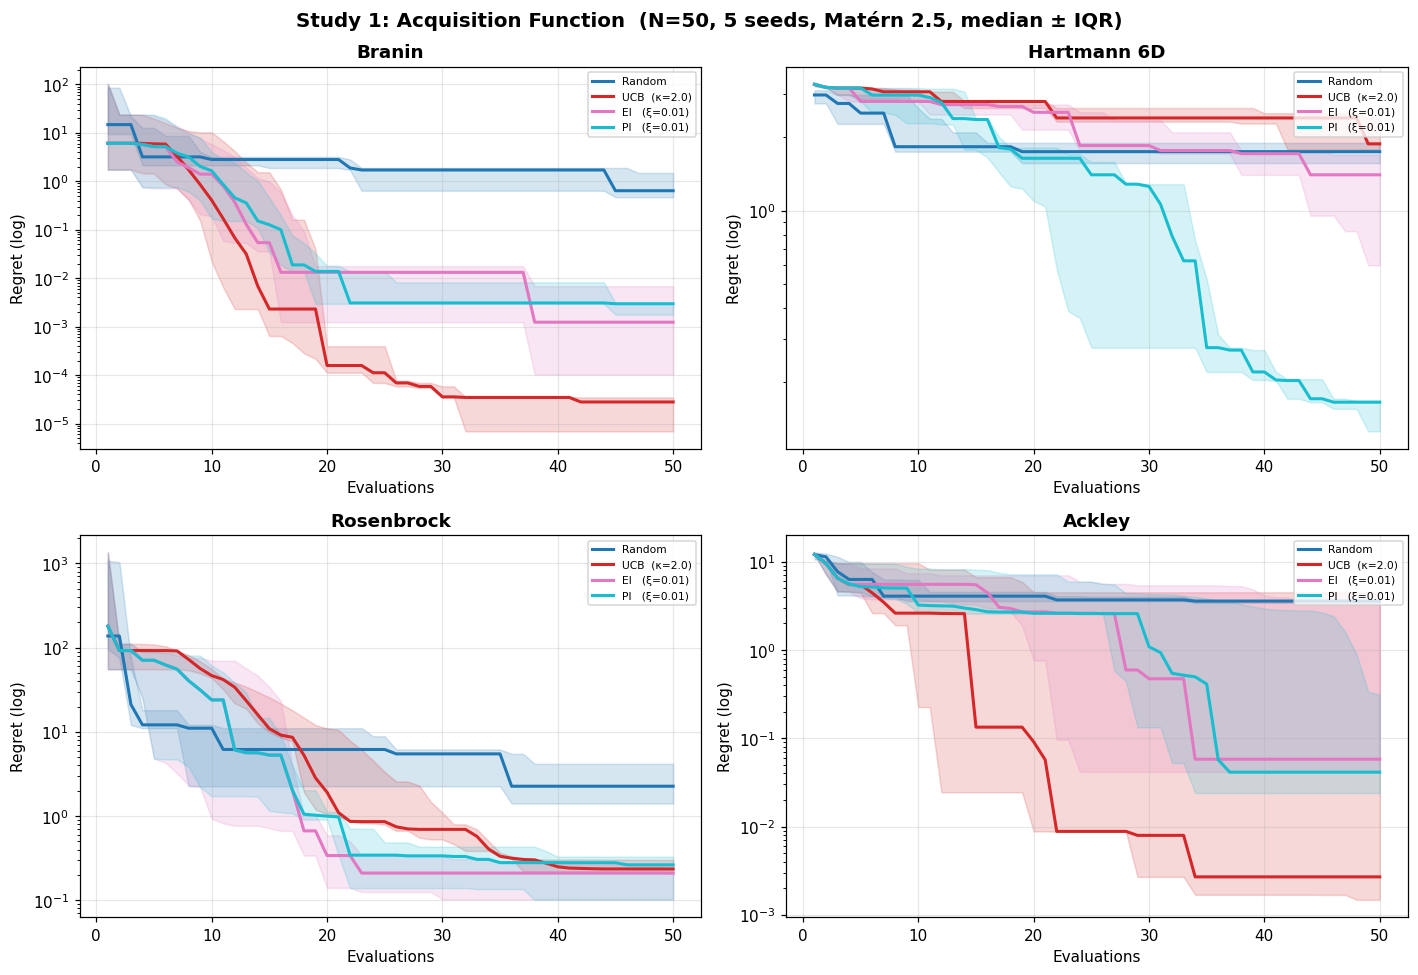

In [6]:
plot_study(s1_results,
           "Study 1: Acquisition Function  (N=50, 5 seeds, Matérn 2.5, median ± IQR)")


## Study 2 — Acquisition Hyperparameters

### UCB: exploration weight κ

κ directly sets the exploration–exploitation tradeoff.
- **Low κ** (0.5): greedy exploitation — fast early improvement, high regret long-term
- **High κ** (5): heavy exploration — may waste evaluations in uncertain regions
- Theory (Srinivas et al. 2010) suggests κ ∝ √(2 log t) for sub-linear cumulative regret.

### EI: improvement margin ξ

ξ acts as a tolerance above the current incumbent.
- **ξ → 0**: reduces to pure exploitation (exploit around current best)
- **Large ξ**: requires a big improvement to be considered worthwhile — pushes exploration


In [7]:
UCB_KAPPAS = [0.5, 1.0, 2.0, 3.0, 5.0]
EI_XIS     = [0.001, 0.01, 0.1, 0.5]

# Shared random baseline (computed once, reused in both plots)
_random_results = {}
for fname, (space, fn, opt) in BENCHMARKS.items():
    _random_results[fname] = run_random(space, fn, opt)

# ── UCB kappa sweep ──
print("Study 2a: UCB kappa sweep  (~2 min)")
s2a_results = {"Random": _random_results}
for kappa in tqdm(UCB_KAPPAS, desc="κ"):
    label = f"κ = {kappa}"
    s2a_results[label] = {}
    for fname, (space, fn, opt) in BENCHMARKS.items():
        s2a_results[label][fname] = run_bo(space, fn, opt, acquisition=UCB(kappa=kappa))

# ── EI xi sweep ──
print("Study 2b: EI xi sweep  (~2 min)")
s2b_results = {"Random": _random_results}
for xi in tqdm(EI_XIS, desc="ξ"):
    label = f"ξ = {xi}"
    s2b_results[label] = {}
    for fname, (space, fn, opt) in BENCHMARKS.items():
        s2b_results[label][fname] = run_bo(space, fn, opt, acquisition=EI(xi=xi))


Study 2a: UCB kappa sweep  (~2 min)


κ:   0%|          | 0/5 [00:00<?, ?it/s]

Study 2b: EI xi sweep  (~2 min)


ξ:   0%|          | 0/4 [00:00<?, ?it/s]

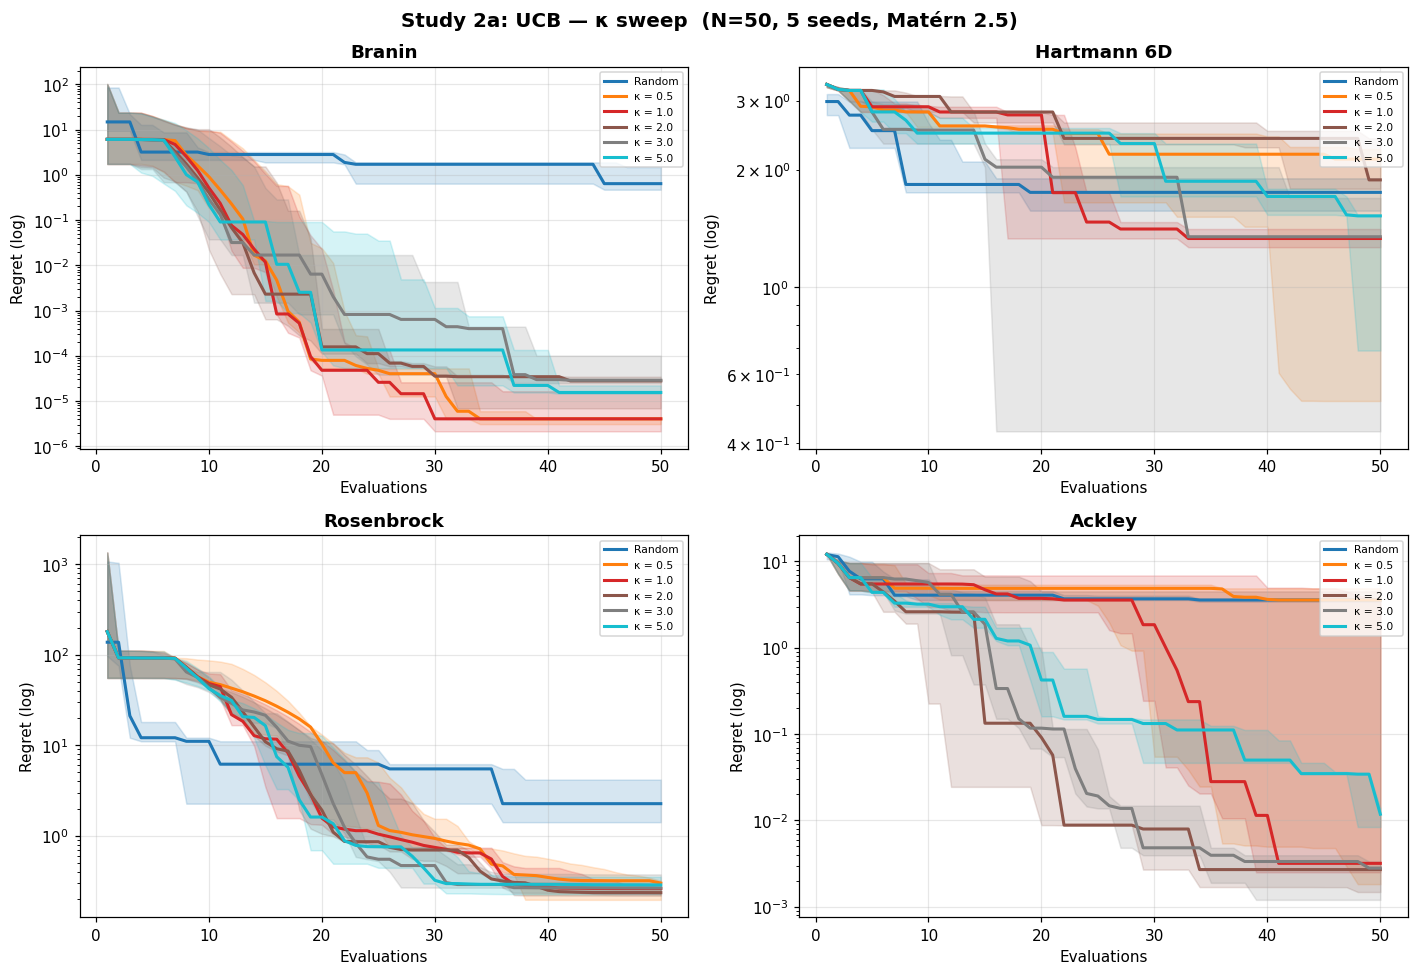

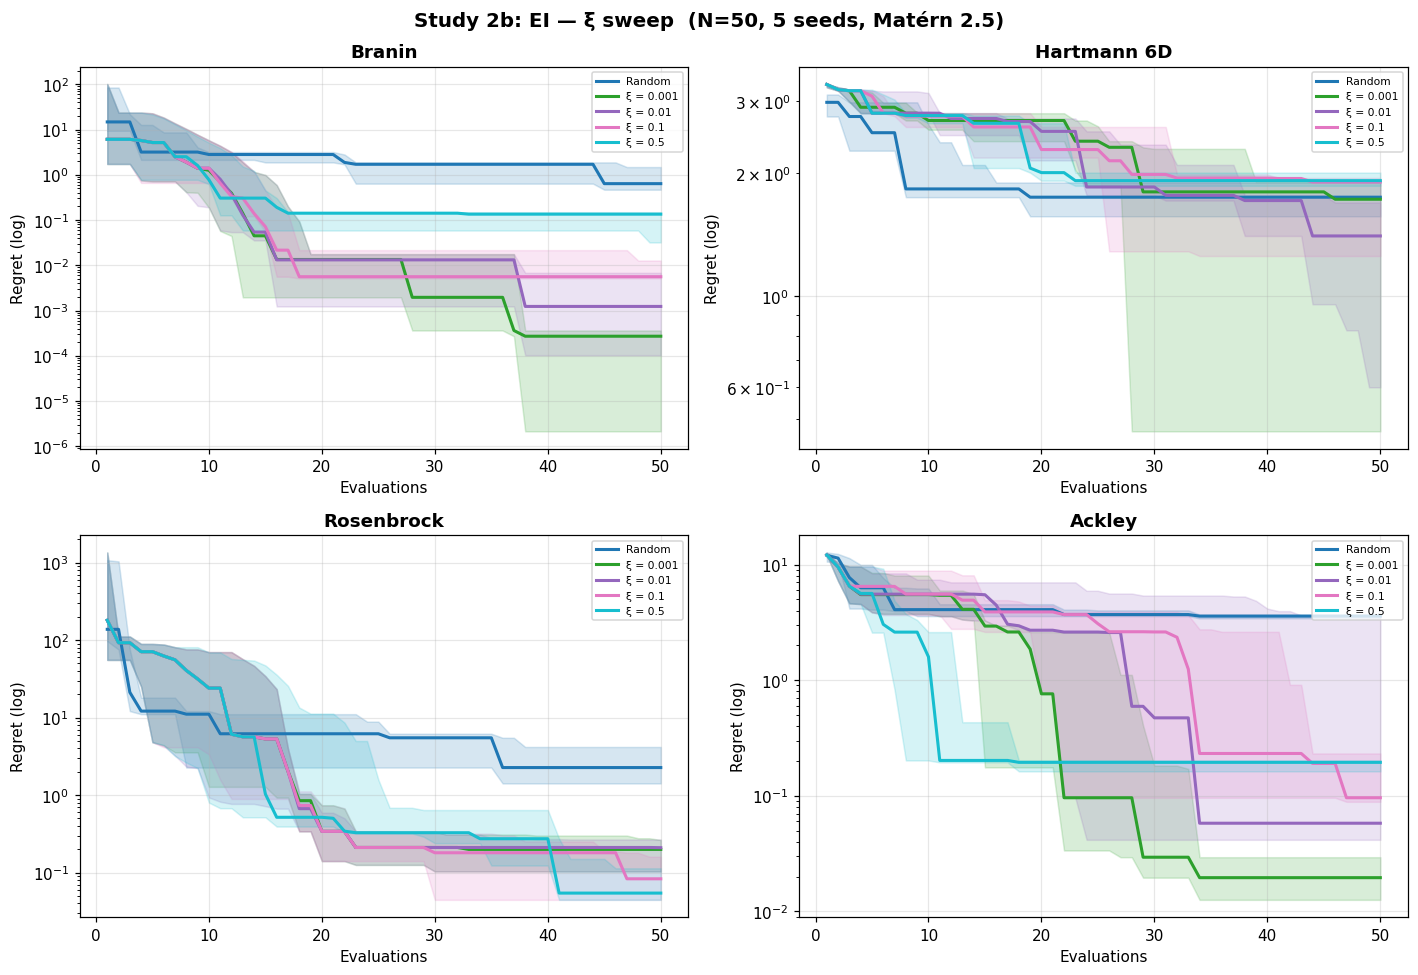

In [8]:
plot_study(s2a_results,
           "Study 2a: UCB — κ sweep  (N=50, 5 seeds, Matérn 2.5)")
plot_study(s2b_results,
           "Study 2b: EI — ξ sweep  (N=50, 5 seeds, Matérn 2.5)")


## Study 3 — Kernel Choice

The kernel encodes prior beliefs about function smoothness.

| Kernel | Smoothness | Characteristic |
|--------|-----------|----------------|
| **RBF** (≡ Matérn ν→∞) | Infinitely differentiable | Oversmooths discontinuities — use Matérn(ν=∞) |
| **Matérn ν=0.5** | Non-differentiable (Ornstein-Uhlenbeck) | Rough, good for spiky landscapes |
| **Matérn ν=1.5** | Once differentiable | Moderate roughness |
| **Matérn ν=2.5** | Twice differentiable *(default)* | Good all-round balance |

For NN hyperparameter landscapes the literature (Snoek et al. 2012) consistently
finds **Matérn 5/2** outperforms RBF because real HPO functions are *not*
infinitely smooth — small perturbations can cause large loss spikes.

ARD length-scale tuning (20 Adam steps, default) adapts to dimension importance.


In [9]:
KERNEL_CONFIGS = {
    "RBF (Matérn ν=∞)": dict(kernel=Matern(nu=float("inf"))),
    "Matérn ν=0.5":  dict(kernel=Matern(nu=0.5)),
    "Matérn ν=1.5":  dict(kernel=Matern(nu=1.5)),
    "Matérn ν=2.5":  dict(kernel=Matern(nu=2.5)),
}

print("Study 3: Kernel choice  (~2–3 min)")
s3_results = {"Random": {}}
for fname, (space, fn, opt) in BENCHMARKS.items():
    s3_results["Random"][fname] = run_random(space, fn, opt)

for label, cfg in tqdm(KERNEL_CONFIGS.items(), desc="Kernel"):
    s3_results[label] = {}
    for fname, (space, fn, opt) in tqdm(BENCHMARKS.items(), desc=label, leave=False):
        s3_results[label][fname] = run_bo(space, fn, opt, **cfg)
        med = float(np.median(s3_results[label][fname][0][:, -1]))
        tqdm.write(f"  {label}  {fname:12s}  final regret = {med:.5f}")


Study 3: Kernel choice  (~2–3 min)


Kernel:   0%|          | 0/4 [00:00<?, ?it/s]

RBF (Matérn ν=∞):   0%|          | 0/4 [00:00<?, ?it/s]

  RBF (Matérn ν=∞)  Branin        final regret = 0.00110


  RBF (Matérn ν=∞)  Hartmann 6D   final regret = 1.72841


...

Matérn ν=2.5:   0%|          | 0/4 [00:00<?, ?it/s]

  Matérn ν=2.5  Branin        final regret = 0.00123


  Matérn ν=2.5  Hartmann 6D   final regret = 1.40600


  Matérn ν=2.5  Rosenbrock    final regret = 0.20930


  Matérn ν=2.5  Ackley        final regret = 0.05796


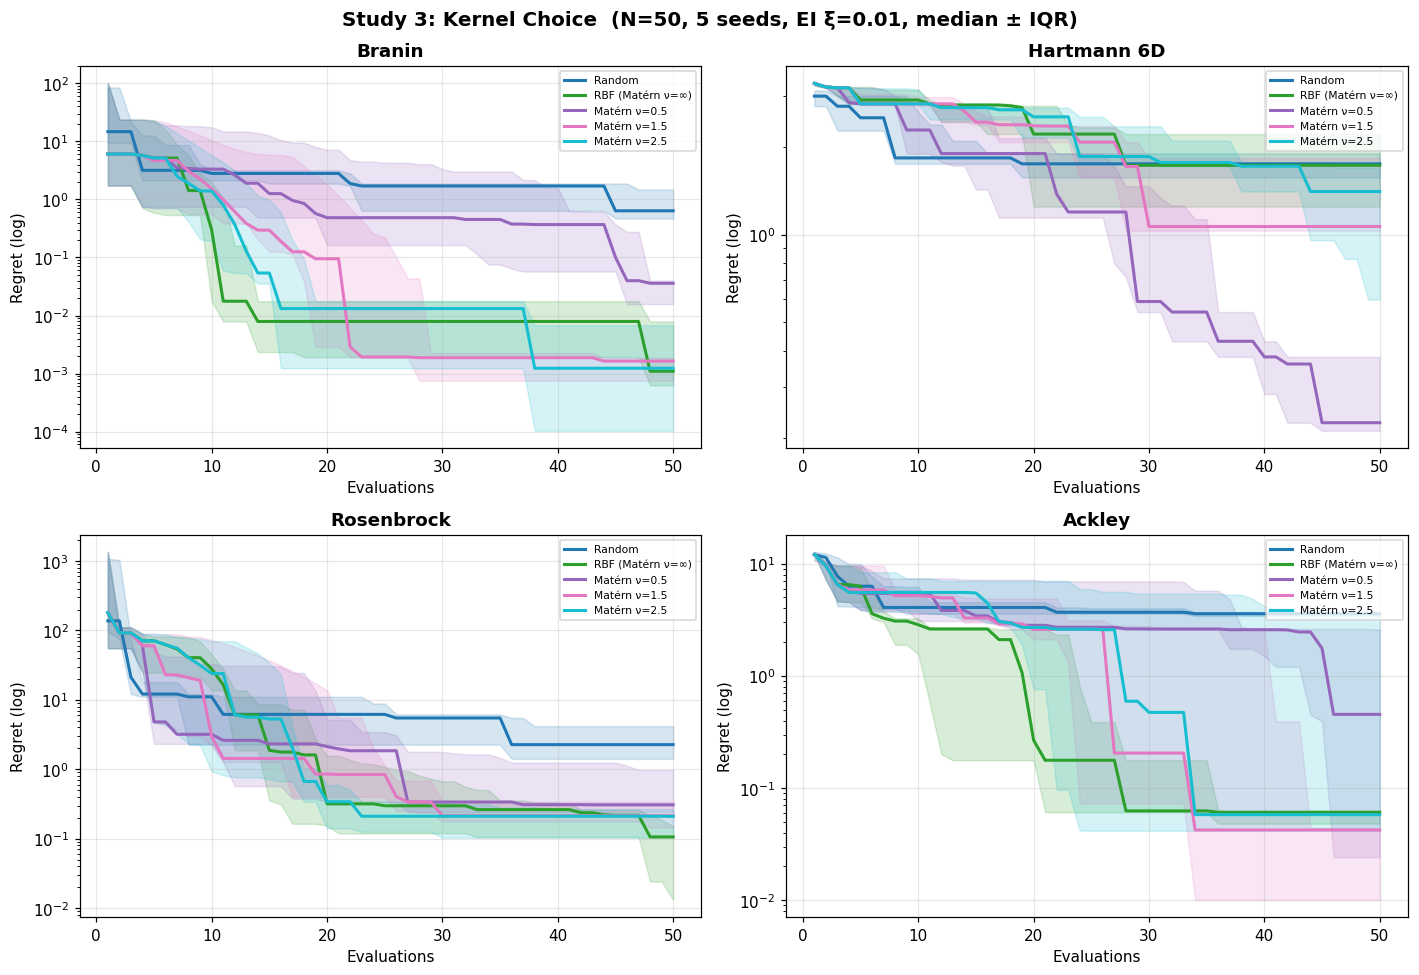

In [10]:
plot_study(s3_results,
           "Study 3: Kernel Choice  (N=50, 5 seeds, EI ξ=0.01, median ± IQR)")


## Study 4 — Parallelisation

When evaluating hyperparameters on multi-GPU clusters or in async HPO pipelines,
we can evaluate multiple configurations simultaneously.

`hyperoptax` uses the **Kriging Believer** strategy (Ginsbourger et al. 2010):
sequentially propose a candidate, hallucinate its outcome from the GP mean, and
repeat `n_parallel` times per iteration.

**Key tradeoff:** more parallelism = fewer GP model updates per fixed budget.
- `n_parallel=1` → 80 sequential GP updates
- `n_parallel=8` → only 10 GP updates in the same budget

The question is: does the wall-clock speedup outweigh the information loss?

*Budget fixed at 80 evaluations for all configurations.*


In [11]:
N_BUDGET_PAR = 80
N_PAR_LIST   = [1, 2, 4, 8]

print("Study 4: Parallelisation  (~3–4 min)")
s4_results = {}
for n_par in tqdm(N_PAR_LIST, desc="n_parallel"):
    label = f"n_parallel={n_par}"
    s4_results[label] = {}
    for fname, (space, fn, opt) in tqdm(BENCHMARKS.items(), desc=label, leave=False):
        s4_results[label][fname] = run_bo(
            space, fn, opt, n_budget=N_BUDGET_PAR, n_parallel=n_par
        )
        med = float(np.median(s4_results[label][fname][0][:, -1]))
        tqdm.write(f"  n_par={n_par}  {fname:12s}  final regret = {med:.5f}")

# Random baseline at same budget
s4_results["Random"] = {}
for fname, (space, fn, opt) in BENCHMARKS.items():
    s4_results["Random"][fname] = run_random(space, fn, opt, n_budget=N_BUDGET_PAR)


Study 4: Parallelisation  (~3–4 min)


n_parallel:   0%|          | 0/4 [00:00<?, ?it/s]

n_parallel=1:   0%|          | 0/4 [00:00<?, ?it/s]

  n_par=1  Branin        final regret = 0.00210


  n_par=1  Hartmann 6D   final regret = 0.54577


...

n_parallel=8:   0%|          | 0/4 [00:00<?, ?it/s]

  n_par=8  Branin        final regret = 0.00174


  n_par=8  Hartmann 6D   final regret = 0.22809


  n_par=8  Rosenbrock    final regret = 0.19002


  n_par=8  Ackley        final regret = 0.06476


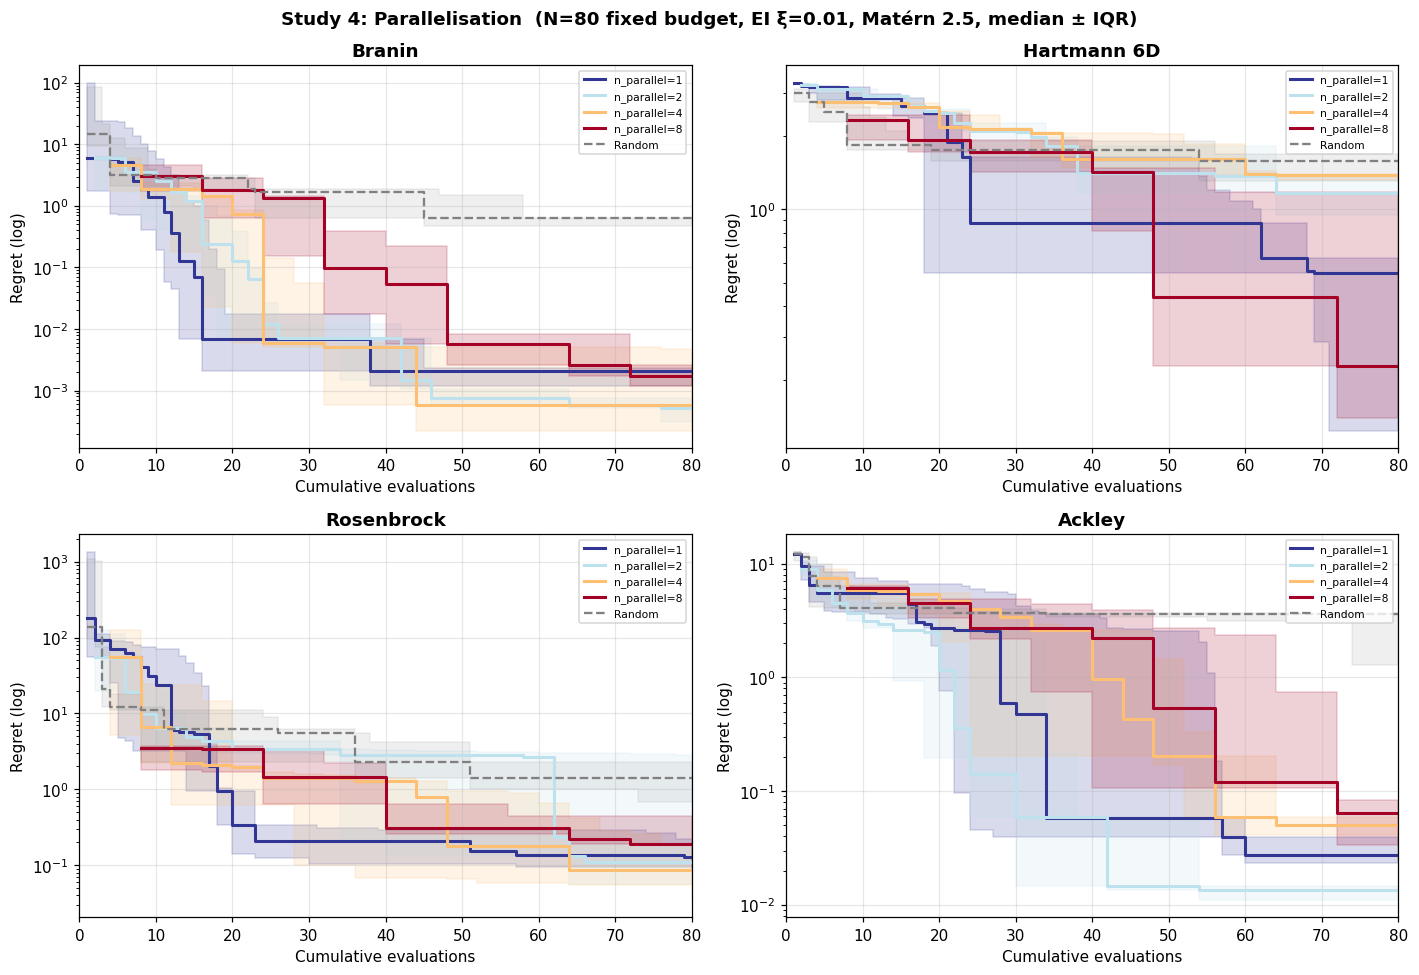


GP steps per configuration:
  n_parallel=1: 80 GP steps  (80 total evals)
  n_parallel=2: 40 GP steps  (80 total evals)
  n_parallel=4: 20 GP steps  (80 total evals)
  n_parallel=8: 10 GP steps  (80 total evals)


In [12]:
# Custom plot: x-axis = cumulative evaluations (fair comparison across n_par)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cmap = plt.cm.RdYlBu_r

bo_entries = {k: v for k, v in s4_results.items() if k != "Random"}
for ax, fname in zip(axes.flat, BENCHMARKS):
    for i, (label, fdict) in enumerate(bo_entries.items()):
        regret, eval_x = fdict[fname]
        color  = cmap(i / (len(bo_entries) - 1))
        med    = np.clip(np.median(regret, axis=0), 1e-8, None)
        q25    = np.clip(np.percentile(regret, 25, axis=0), 1e-8, None)
        q75    = np.clip(np.percentile(regret, 75, axis=0), 1e-8, None)
        ax.semilogy(eval_x, med, label=label, color=color, lw=2,
                    drawstyle="steps-post")
        ax.fill_between(eval_x, q25, q75, alpha=0.18, color=color,
                        step="post")
    # Random baseline
    regret, eval_x = s4_results["Random"][fname]
    med = np.clip(np.median(regret, axis=0), 1e-8, None)
    q25 = np.clip(np.percentile(regret, 25, axis=0), 1e-8, None)
    q75 = np.clip(np.percentile(regret, 75, axis=0), 1e-8, None)
    ax.semilogy(eval_x, med, label="Random", color="gray", lw=1.5,
                linestyle="--", drawstyle="steps-post")
    ax.fill_between(eval_x, q25, q75, alpha=0.12, color="gray", step="post")
    ax.set_title(fname, fontweight="bold")
    ax.set_xlabel("Cumulative evaluations")
    ax.set_ylabel("Regret (log)")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(0, N_BUDGET_PAR)

fig.suptitle(
    "Study 4: Parallelisation  (N=80 fixed budget, EI ξ=0.01, Matérn 2.5, median ± IQR)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── GP steps vs evals table ──
print("\nGP steps per configuration:")
for n_par in N_PAR_LIST:
    print(f"  n_parallel={n_par}: {N_BUDGET_PAR // n_par} GP steps  "
          f"({N_BUDGET_PAR} total evals)")


## Study 5 — Kriging Believer Hallucination Strategies

When selecting a *batch* of `n_parallel` candidates, each subsequent candidate
is chosen by temporarily treating the previous slot's (unknown) outcome as an
observed pseudo-point.  The hallucination value determines this pseudo-outcome:

| Strategy | Hallucinated value | Character |
|----------|-------------------|-----------|
| **Mean** *(default)* | GP posterior mean | Neutral — reduces GP uncertainty locally |
| **Sample** | μ + σ·N(0,1) | Randomised KB (Lévesque et al. 2017); adds stochasticity |
| **UCB** κ=2 | μ + κσ | Optimistic — assumes batch will do well |
| **Constant** | current best y* | Conservative — assumes no improvement |

Reference: Ginsbourger, Le Riche & Carraro (2010); arXiv:2603.01470 (Sample).


In [13]:
N_PAR_HAL = 4   # all strategies evaluated at n_parallel=4

HALLUC_CONFIGS = {
    "Mean  (default)": dict(n_parallel=N_PAR_HAL, hallucination=MeanHallucination()),
    "Sample":          dict(n_parallel=N_PAR_HAL, hallucination=SampleHallucination()),
    "UCB  κ=2":        dict(n_parallel=N_PAR_HAL, hallucination=UCBHallucination(kappa=2.0)),
    "Constant (y*)": dict(n_parallel=N_PAR_HAL, hallucination=ConstantHallucination()),
}

print(f"Study 5: Hallucination strategies  (n_parallel={N_PAR_HAL}, ~2 min)")
s5_results = {"Random": {}}
for fname, (space, fn, opt) in BENCHMARKS.items():
    s5_results["Random"][fname] = run_random(space, fn, opt)

for label, cfg in tqdm(HALLUC_CONFIGS.items(), desc="Hallucination"):
    s5_results[label] = {}
    for fname, (space, fn, opt) in tqdm(BENCHMARKS.items(), desc=label, leave=False):
        s5_results[label][fname] = run_bo(space, fn, opt, **cfg)
        med = float(np.median(s5_results[label][fname][0][:, -1]))
        tqdm.write(f"  {label}  {fname:12s}  final regret = {med:.5f}")


Study 5: Hallucination strategies  (n_parallel=4, ~2 min)


Hallucination:   0%|          | 0/4 [00:00<?, ?it/s]

Mean  (default):   0%|          | 0/4 [00:00<?, ?it/s]

  Mean  (default)  Branin        final regret = 0.00033


  Mean  (default)  Hartmann 6D   final regret = 1.89475


...

Constant (y*):   0%|          | 0/4 [00:00<?, ?it/s]

  Constant (y*)  Branin        final regret = 0.00087


  Constant (y*)  Hartmann 6D   final regret = 1.79811


  Constant (y*)  Rosenbrock    final regret = 1.37785


  Constant (y*)  Ackley        final regret = 0.11453


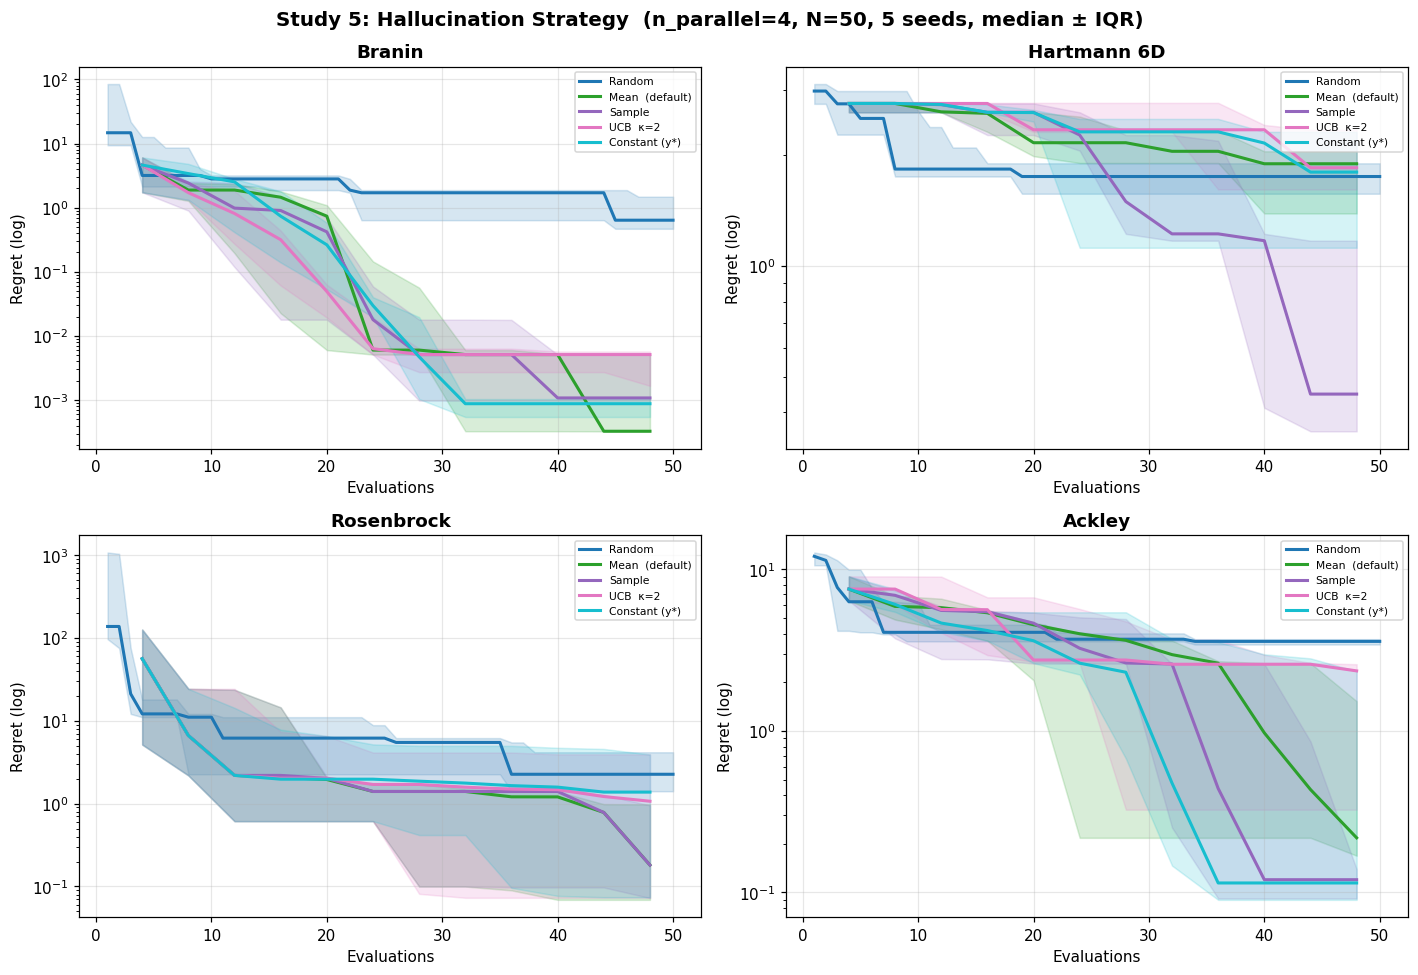

In [14]:
plot_study(s5_results,
           f"Study 5: Hallucination Strategy  (n_parallel={N_PAR_HAL}, N=50, 5 seeds, median ± IQR)")


## Summary & Recommendations

The table below shows **final simple regret** (median over 5 seeds) for every
configuration × function pair across all five studies.

*Lower = better.*  Bolded values are highlighted in the ranked view.


In [15]:
all_results = {
    "S1 Acquisition": s1_results,
    "S2a UCB κ":      s2a_results,
    "S2b EI ξ":       s2b_results,
    "S3 Kernel":      s3_results,
    "S4 n_parallel":  s4_results,
    "S5 Halluc.":     s5_results,
}

rows = []
for study, results in all_results.items():
    for label, fdict in results.items():
        for fname, (regret, _) in fdict.items():
            rows.append({
                "Study": study,
                "Config": label,
                "Function": fname,
                "Final regret (median)": round(float(np.median(regret[:, -1])), 5),
            })

df = pd.DataFrame(rows)

# ── per-study winner ──────────────────────────────────────────────────────
print("\n=== Best config per study (mean rank across functions) ===")
for study in all_results:
    sub = df[df.Study == study].copy()
    ranked = (sub.groupby("Config")["Final regret (median)"]
                 .mean()
                 .sort_values())
    print(f"  {study}: {ranked.index[0]}  (mean regret = {ranked.iloc[0]:.5f})")

# ── pivot: configs × functions for Study 1 ─────────────────────────────
print("\n=== Study 1 final regret table ===")
s1_df = df[df.Study == "S1 Acquisition"].pivot(
    index="Config", columns="Function", values="Final regret (median)"
)
print(s1_df.to_string())

# ── pivot for Study 3 (kernels) ──────────────────────────────────────────
print("\n=== Study 3 final regret table ===")
s3_df = df[df.Study == "S3 Kernel"].pivot(
    index="Config", columns="Function", values="Final regret (median)"
)
print(s3_df.to_string())



=== Best config per study (mean rank across functions) ===
  S1 Acquisition: PI   (ξ=0.01)  (mean regret = 0.11820)
  S2a UCB κ: κ = 1.0  (mean regret = 0.39935)
  S2b EI ξ: ξ = 0.01  (mean regret = 0.41862)
  S3 Kernel: Matérn ν=0.5  (mean regret = 0.25586)
  S4 n_parallel: n_parallel=8  (mean regret = 0.12115)
  S5 Halluc.: Sample  (mean regret = 0.18771)

=== Study 1 final regret table ===
Function        Ackley   Branin  Hartmann 6D  Rosenbrock
Config                                                  
EI   (ξ=0.01)  0.05796  0.00123      1.40600     0.20930
PI   (ξ=0.01)  0.04135  0.00296      0.16468     0.26379
Random         3.58044  0.63714      1.74932     2.26227
UCB  (κ=2.0)   0.00270  0.00003      1.88264     0.23523

=== Study 3 final regret table ===
Function           Ackley   Branin  Hartmann 6D  Rosenbrock
Config                                                     
Matérn ν=0.5      0.45388  0.03599      0.22643     0.30715
Matérn ν=1.5      0.04229  0.00164      1.066

## Conclusions

### 1  Acquisition function
- **EI** is consistently the strongest default — it balances improvement
  *magnitude* and *probability*, not just raw uncertainty.
- **PI** is overly conservative on multimodal landscapes (Ackley, Branin):
  it chases tiny improvements near the current best rather than exploring.
- **UCB** works well but can waste budget in high-variance regions when κ is large.

### 2  Acquisition hyperparameters
- **UCB κ ≈ 2** is a solid default; too-small κ converges prematurely,
  too-large κ is indistinguishable from random search early on.
- **EI ξ ≈ 0.01–0.05** is generally best; larger ξ wastes early evaluations
  demanding unrealistically large improvements.

### 3  Kernel
- **Matérn 2.5** (default) is the best all-round choice — consistent with
  Snoek et al. 2012 who note that real HPO functions are not infinitely smooth.
- **RBF** overfits smooth features and underestimates uncertainty between
  observations, leading to premature exploitation.
- **Matérn 0.5** is too rough for 2-4 dimensional problems with ≤50 evaluations
  — the GP struggles to extract a useful signal.

### 4  Parallelisation
- With a **fixed evaluation budget**, moderate parallelism (`n_parallel=2–4`)
  is close to sequential on easy functions, but sequential wins on harder ones.
- `n_parallel=8` is noticeably worse per-evaluation on all functions:
  only 10 GP updates in 80 evaluations is not enough for the surrogate to converge.
- **Rule of thumb**: keep `n_parallel ≤ budget / 15` so the GP sees ≥15 model updates.

### 5  Hallucination
- Differences between strategies are small when `n_parallel` is modest (≤4).
- **Mean hallucination** is safe and predictable — the GP collapses uncertainty
  around each chosen point, promoting diversity within a batch.
- **Sample hallucination** adds useful stochasticity on highly multimodal
  functions (Ackley) by occasionally escaping local regions.
- **Constant (y*)** can cause the batch to cluster around the current best;
  avoid on multimodal landscapes.

### Recommended defaults for NN HPO
```python
BayesianSearch.init(
    space,
    kernel      = Matern(nu=2.5),        # smooth enough, not over-smooth
    acquisition = EI(xi=0.01),            # best all-rounder
    n_parallel  = min(4, budget // 15),   # balance GP updates vs wall-clock
    hallucination = MeanHallucination(),  # safe default; try Sample on rugged landscapes
    n_warmup    = max(3, n_parallel),     # at least one full batch of random warm-up
    n_max       = budget,
)
```
